In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "whitegrid")
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/data_cleaned.csv")
df.head()

,Unnamed: 0,loan_amnt,term,int_rate,annual_inc,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,mort_acc,pub_rec_bankruptcies,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,application_type_INDIVIDUAL,application_type_JOINT,zip_code_05113,zip_code_11650,zip_code_22690,zip_code_29597,zip_code_30723,zip_code_48052,zip_code_70466,zip_code_86630,zip_code_93700
0,0,10000.0,0,11.44,117000.0,0,26.24,16.0,0,36369.0,41.8,25.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0
1,1,8000.0,0,11.99,65000.0,0,22.05,17.0,0,20131.0,53.3,27.0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
2,2,15600.0,0,10.49,43057.0,0,12.79,13.0,0,11987.0,92.2,26.0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0
3,3,7200.0,0,6.49,54000.0,0,2.60,6.0,0,5472.0,21.5,13.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,4,24375.0,1,17.27,55000.0,1,33.95,13.0,0,24584.0,69.8,43.0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0


In [4]:
# separating features (x) and target (y)
x = df.drop(columns = ["loan_status"])
y = df["loan_status"]

In [5]:
# splitting the data into training and testing datasets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, stratify = y, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((190202, 51), (47551, 51), (190202,), (47551,))

In [6]:
# model training
from sklearn.linear_model import LogisticRegression

lgr_model = LogisticRegression()
lgr_model.fit(x_train, y_train)

LogisticRegression()

In [7]:
# saving the model into a .pkl file
import pickle

with open("../artifacts/lgr_model.pkl", "wb") as f:
    pickle.dump(lgr_model, f)

In [8]:
# prediction
y_pred = lgr_model.predict(x_test)

In [10]:
# evaluation of model's performance

# accuracy
def lgr_model_accuracy(y_true, y_preds):
    return np.sum(y_true == y_preds)/len(y_true)

model_accuracy = lgr_model_accuracy(y_test, y_pred)
print(f"Accuracy of the Logistic Regression on the Test Data = {model_accuracy}")

Accuracy of the Logistic Regression on the Test Data = 0.8029904733864692


In [11]:
# accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8029904733864692

[[38074   136]
 [ 9232   109]]


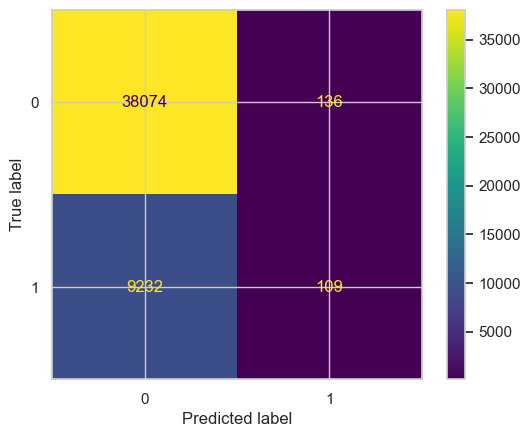

In [12]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

cm = ConfusionMatrixDisplay(confusion_matrix = cm)
cm.plot()
plt.savefig("../artifacts/confusion_matrix.png")
plt.show()

ROC AUC Scores = 0.6235007317193919


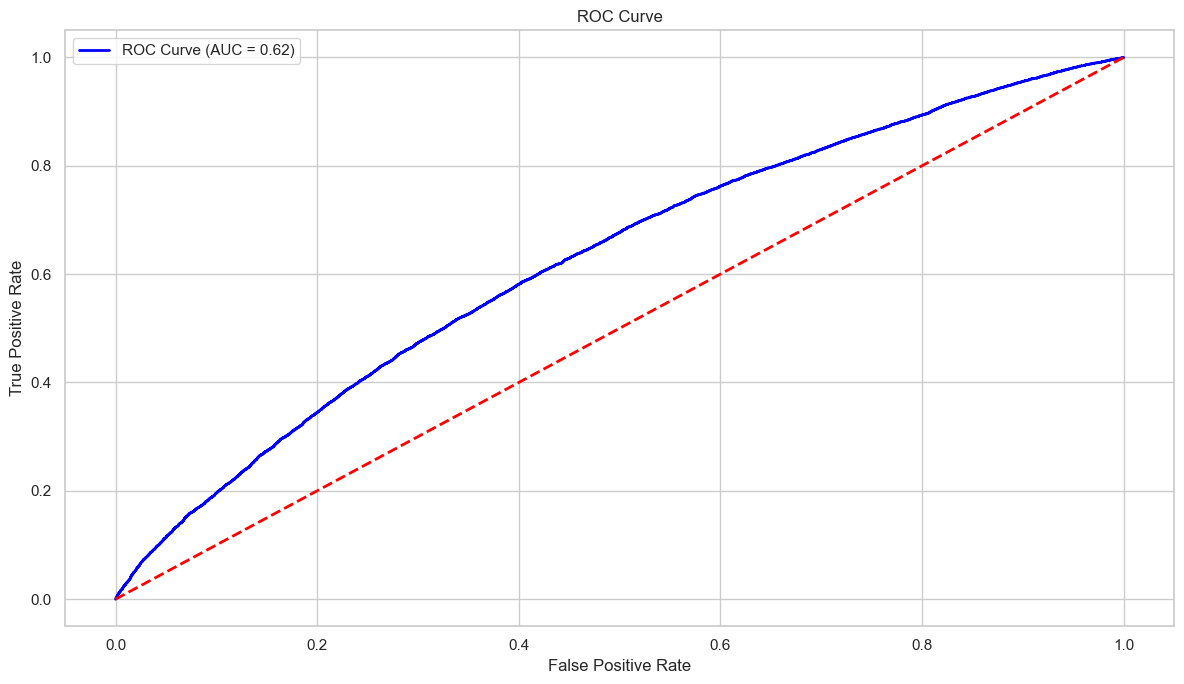

In [13]:
# roc auc curve
from sklearn.metrics import roc_auc_score, auc, roc_curve

y_pred_proba = lgr_model.predict_proba(x_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test, y_pred_proba)
# score = roc_auc_score(y_test, y_pred_proba)
score = auc(fpr, tpr)

print(f"ROC AUC Scores = {score}")

plt.figure(figsize = (12, 7))
plt.plot(fpr, tpr, color = "blue", lw = 2, label = "ROC Curve (AUC = {:.2f})".format(score))
plt.plot([0, 1], [0, 1], color = "red", linestyle = "--", lw = 2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../artifacts/roc_curve.png")
plt.show()

PR AUC Score = 0.281925227289771


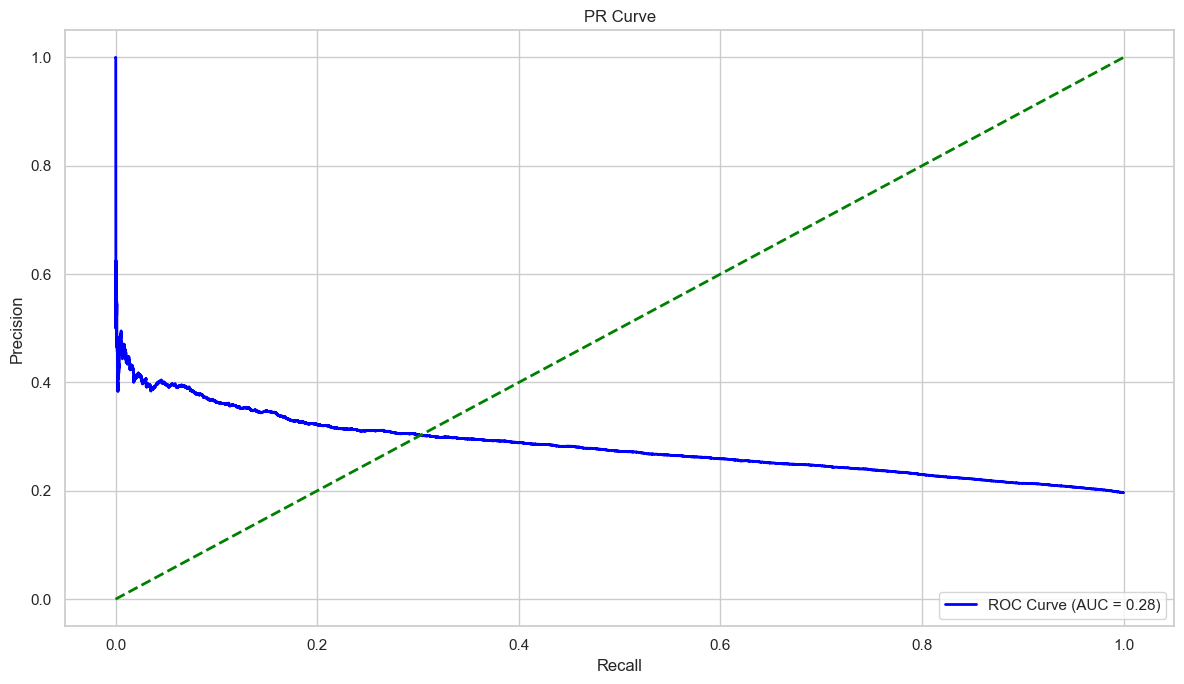

In [14]:
# pr curve
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print(f"PR AUC Score = {pr_auc}")

plt.figure(figsize = (12, 7))
plt.plot(recall, precision, color = "blue", lw = 2, label = "ROC Curve (AUC = {:.2f})".format(pr_auc))
plt.plot([0, 1], [0, 1], color = "green", linestyle = "--", lw = 2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.legend()
plt.tight_layout()
plt.savefig("../artifacts/pr_curve.png")
plt.show()

In [15]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n\nClassification Report")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[38074   136]
 [ 9232   109]]


Classification Report
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38210
           1       0.44      0.01      0.02      9341

    accuracy                           0.80     47551
   macro avg       0.62      0.50      0.46     47551
weighted avg       0.73      0.80      0.72     47551



In [16]:
# model coefficients
coefficients = lgr_model.coef_[0]
feature_names = x.columns

df_coef = pd.DataFrame(
    {
        "Column Name": feature_names, 
        "Coefficient": coefficients
    }
).sort_values(by = "Coefficient", ascending = False)
df_coef

,Column Name,Coefficient
3,int_rate,0.042368
5,dti,0.011280
2,term,0.007210
50,zip_code_93700,0.006538
43,zip_code_11650,0.006509
49,zip_code_86630,0.006505
17,grade_E,0.003527
16,grade_D,0.003206
18,grade_F,0.001570
25,verification_status_Source Verified,0.001473
